# 70% Compliance Assessment for DK1 and DK2

This notebook analyses Flow-Based compliance for **DK1** and **DK2** with a focus on Energinet data.  
The purpose is to compare different compliance methodologies and understand how transmission constraints affect cross-zonal capacity.

## Structure of the analysis

The notebook is divided into several sections:

### 1. ACER recommendation and compliance for DK1 and DK2
In this section, we analyse compliance for **DK1** and **DK2** based on the ACER-oriented methodology.  
The purpose is to evaluate whether the available margin offered to the market is consistent with the ACER 70% target.

### 2. CNEC-hours method or % of constraint method
This section evaluates compliance based on the **share of compliant CNECs per hour**.  
In other words, for each market time unit, we assess how many of the relevant CNECs satisfy the compliance criterion.

### 3. Weighted CNEC-hours method
Here, we refine the CNEC-hours perspective by introducing a weighted approach.  
This method shows **what percentage of the physcial power system is compliant**, giving more importance to CNECs with greater market relevance.

### 4. Shadow price analysis
In this section, we investigate **shadow prices** in order to identify when constraints become economically binding.  
This helps reveal which CNECs are most important in limiting market outcomes.

### 5. RTE compliance method
This section applies the **RTE-inspired compliance methodology**, offering an alternative perspective on compliance assessment and allowing comparison with the previous methods.

### 6. Influence on Viking Link in the first two months of 2026
Finally, we analyse the impact of the compliance results and constraints on **Viking Link** during **January and February 2026**.  
The objective is to understand whether the forcasted flows will change the compliance estimations

---

The analysis is based on parsed Flow-Based domain data, filtered to:
- **Energinet**
- **Branch CNECs**
- rows where **`fmax != 0`**

This ensures that the study focuses on physically meaningful constraints relevant for the Danish bidding zones.
The data that is in the parquet files are from the public availble https://publicationtool.jao.eu/nordic/flowbasedDomain
The data in CSV is requested from the NRCC


In [1]:
import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt   # Plotting and visualization

# Automatically reload imported modules during development
%load_ext autoreload

# Reload modules every time before executing code
%autoreload 2

In [2]:
# Import functions used to parse Flow-Based data files from folders
# These utilities load multiple files and combine them into a single DataFrame
from folder_parser import folder_parser
from folder_parser import folder_parser_csv

# Import the different compliance methodologies used in the analysis
# Each module implements a specific method for evaluating 70% compliance
from compliance_methods import acer_method
from compliance_methods import cnec_hours_method
from compliance_methods import market_ratio_method
from compliance_methods import shadow_price_method
from compliance_methods import france_method
from compliance_methods import viking_link_MNCC

# Import plotting utilities used to visualize compliance results
# These functions generate figures for market compliance and raw metrics
# these are based on the plots in the ENtsoe market report
from plotter import entsoe_market_plotting
from plotter import raw_compliance_plotting


### 1. ACER recommendation and compliance for DK1 and DK2
In this section, we analyse compliance for **DK1** and **DK2** based on the ACER-oriented methodology.  
The purpose is to evaluate whether the available margin offered to the market is consistent with the ACER 70% target.

In [3]:



filepath = r'C:\Users\JAEOL\OneDrive - Energinet.dk\Skrivebord\2026\FSTS\Market.Coupling.FSTS\2025_FB_domain_data_parquet' # just the filepath for all the FB data, that is published at JAO
df_flowbased_domain = folder_parser.parse_folder_to_dataframe(filepath)
df_flowbased_domain  = df_flowbased_domain[df_flowbased_domain['tso'] == 'ENERGINET']
df_flowbased_domain= df_flowbased_domain[df_flowbased_domain['cnecType'] == 'BRANCH']
df_flowbased_domain  =  df_flowbased_domain[df_flowbased_domain['fmax'] != 0] # filtering out relevant rows where fmax is not zero  



Reading file: flowbased_rev2_2025_01.parquet
Reading file: flowbased_rev2_2025_02.parquet
Reading file: flowbased_rev2_2025_03.parquet
Reading file: flowbased_rev2_2025_04.parquet
Reading file: flowbased_rev2_2025_05.parquet
Reading file: flowbased_rev2_2025_06.parquet
Reading file: flowbased_rev2_2025_07.parquet
Reading file: flowbased_rev2_2025_08.parquet
Reading file: flowbased_rev2_2025_09.parquet
Reading file: flowbased_rev2_2025_10.parquet
Reading file: flowbased_rev2_2025_11.parquet
Reading file: flowbased_rev2_2025_12.parquet

Files read: 12
Combined dataframe shape: (17073783, 69)


In [4]:
# RECOMMENDATION No 01/2019  OF THE EUROPEAN UNION AGENCY FOR THE COOPERATION OF ENERGY REGULATORS  defines the 70% compliance as the sum of RAM and AAC over Fmax, thus we need to calculate this ratio for all methods, as it is the basis for all the compliance calculations.
# Note that for the Viking Link, we also have the MNCC, but this is not a part of this dataset
# We will calculate the influence of MNCC in the Viking Link dataset, but for the public flow-based domain, we will stick to the RAM and AAC as defined in the recommendation.
df_flowbased_domain['ratio'] = (df_flowbased_domain['ram']+df_flowbased_domain['aac'])/df_flowbased_domain['fmax'] # this is need for all methods note ratio here means the MAZCT


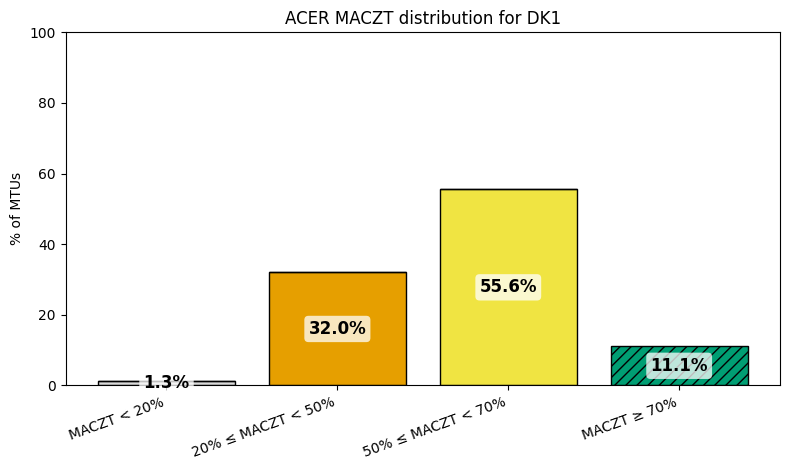

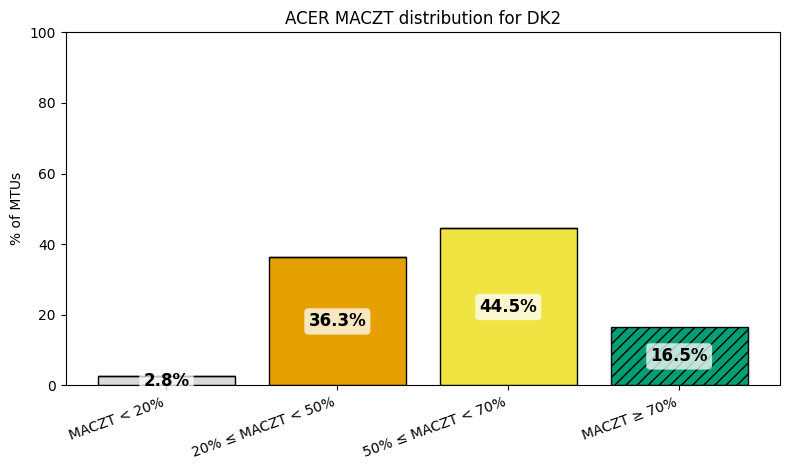

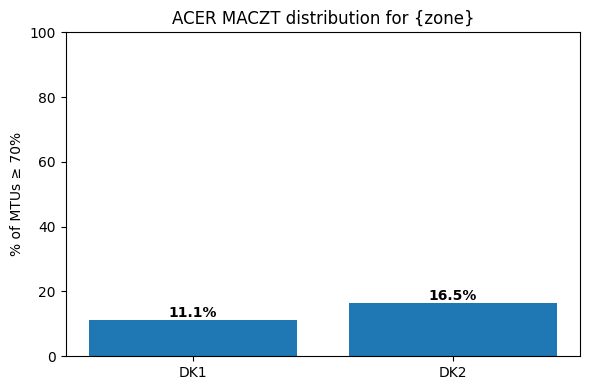

In [5]:
# Run the ACER compliance method for the Danish bidding zones DK1 and DK2
# This calculates the compliance ratio for each MTU based on the ACER methodology
# This always looks at the worst Compliant CNEC
df_acer = acer_method.run_acer_method(df_flowbased_domain, zones=['DK1', 'DK2']) 

# Plot the compliance results over time for all selected zones
# This gives a visual plot like the entsoe market report
entsoe_market_plotting.plot_all_acer_zones(df_acer, zones=["DK1", "DK2"], title_template="ACER MACZT distribution for {zone}")

# Plot the percentage of hours where the compliance ratio is above 70%
# This helps evaluate whether the zones meet the regulatory 70% requirement
raw_compliance_plotting.plot_pct_above_70(df_acer,  title_template="ACER MACZT distribution for {zone}")


### 2. CNEC-hours method
This section evaluates compliance based on the **share of compliant CNECs per hour**.  
In other words, for each market time unit, we assess how many of the relevant CNECs satisfy the compliance criterion.

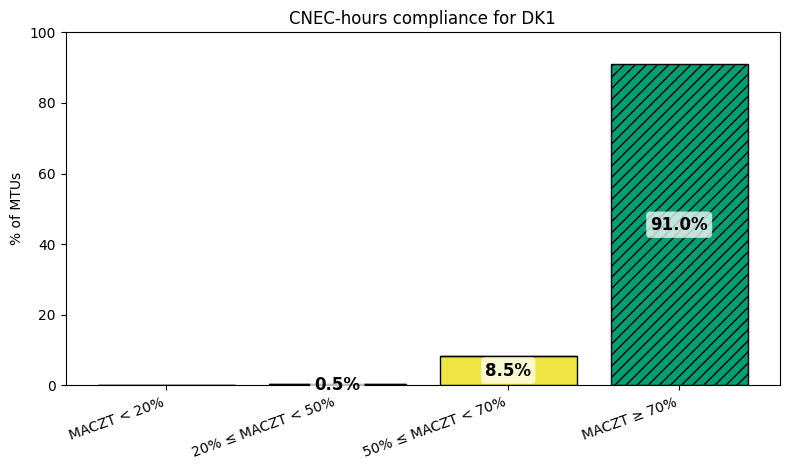

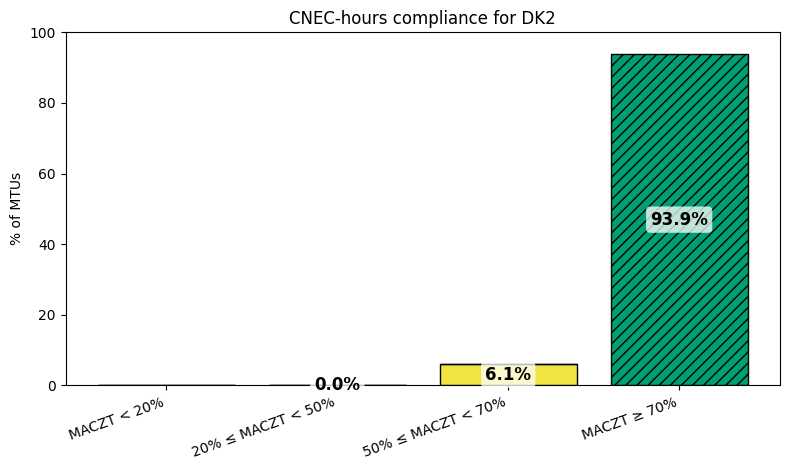

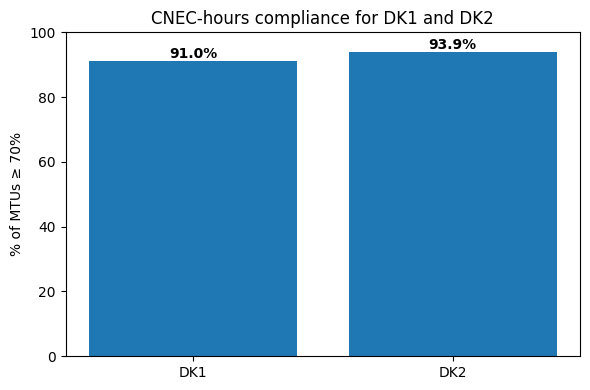

In [6]:
# Run the CNEC-hours compliance method
# For each hour (MTU) and bidding zone, this calculates the share of CNECs
# that satisfy the compliance threshold (ratio >= 0.7)
cnec_hours_df = cnec_hours_method.run_cnec_hours_method(df_flowbased_domain)
entsoe_market_plotting.plot_all_acer_zones(cnec_hours_df,  zones=['DK1', 'DK2'], title_template="CNEC-hours compliance for {zone}")
raw_compliance_plotting.plot_pct_above_70(cnec_hours_df, title_template="CNEC-hours compliance for DK1 and DK2")

### 3. Weighted CNEC-hours method
Here, we refine the CNEC-hours perspective by introducing a weighted approach.  
This method shows **what percentage of the constrained system is compliant**, giving more importance to CNECs with greater market relevance.


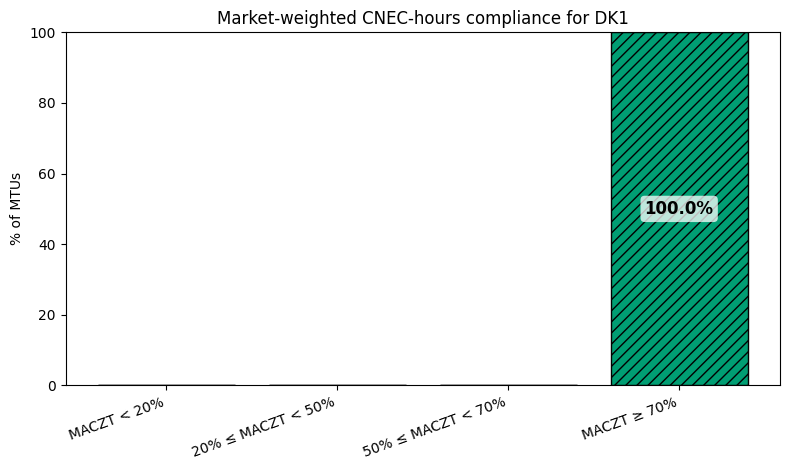

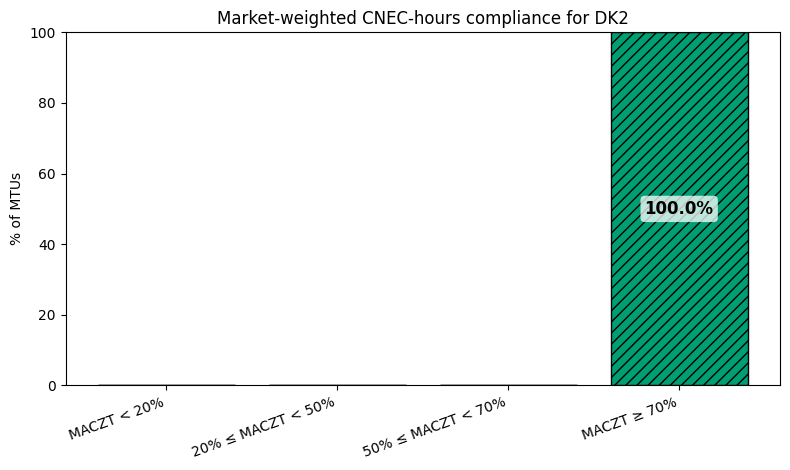

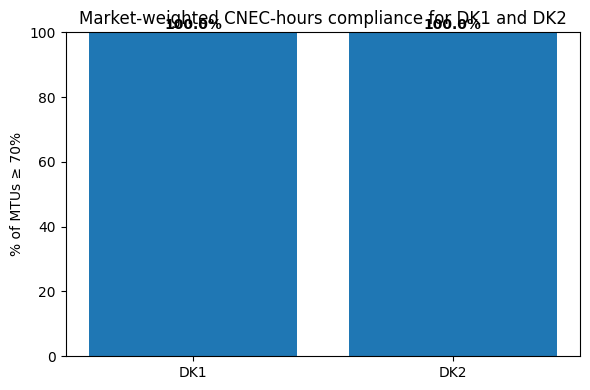

In [7]:
# Run the weighted CNEC-hours compliance method
# This method evaluates compliance by weighting CNECs according to their
# market relevance (e.g., available capacity)
cnec_hours_market_weighted_df = market_ratio_method.run_cnec_hours_market_weighted_method(df_flowbased_domain)
entsoe_market_plotting.plot_all_acer_zones(cnec_hours_market_weighted_df, zones=['DK1', 'DK2'], title_template="Market-weighted CNEC-hours compliance for {zone}")
raw_compliance_plotting.plot_pct_above_70(cnec_hours_market_weighted_df, title_template="Market-weighted CNEC-hours compliance for DK1 and DK2")


### 4. Shadow price analysis
In this section, we investigate **shadow prices** in order to identify when constraints become economically binding.  
This helps reveal which CNECs are most important in limiting market outcomes.



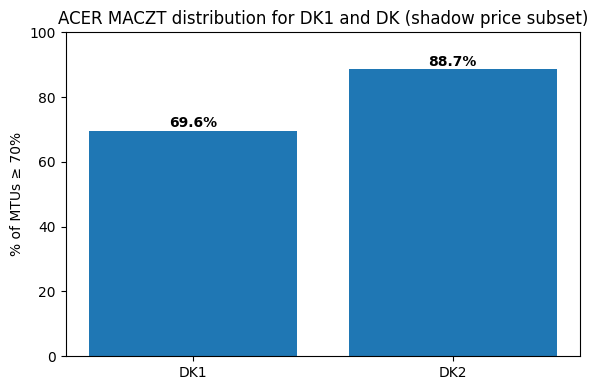

In [8]:
# Identify CNECs that have a shadow price
# This filters the dataset to the constraints that were economically binding in the market
shadow_price_df = shadow_price_method.run_shadow_price_method(df_flowbased_domain)
# Apply the ACER compliance method on the subset of CNECs with shadow prices
# This allows us to evaluate compliance only for the constraints that actually influenced the market outcome
df_acer = acer_method.run_acer_method(shadow_price_df, zones=['DK1', 'DK2'])
raw_compliance_plotting.plot_pct_above_70(df_acer, title_template="ACER MACZT distribution for DK1 and DK (shadow price subset)")


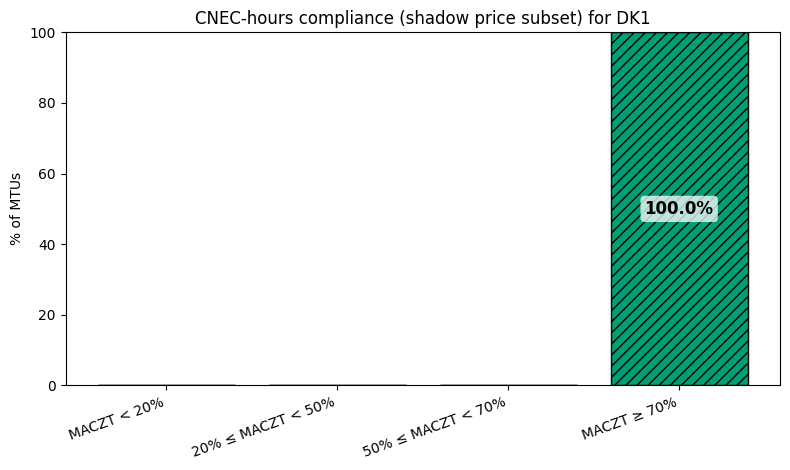

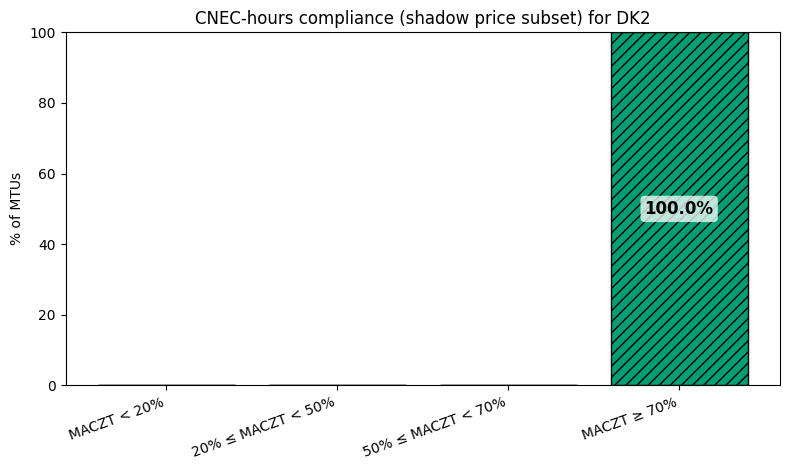

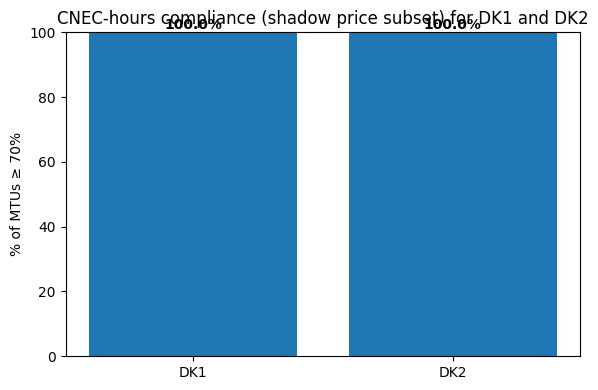

In [9]:
# Apply the CNEC-hours compliance method on the subset of CNECs with shadow prices

cnec_hours_df = cnec_hours_method.run_cnec_hours_method(shadow_price_df)
entsoe_market_plotting.plot_all_acer_zones(cnec_hours_df, zones=['DK1', 'DK2'], title_template="CNEC-hours compliance (shadow price subset) for {zone}")
raw_compliance_plotting.plot_pct_above_70(cnec_hours_df, title_template="CNEC-hours compliance (shadow price subset) for DK1 and DK2")



### 5. RTE compliance method
This section applies the **RTE-inspired compliance methodology**, offering an alternative perspective on compliance assessment and allowing comparison with the previous methods.

In [10]:
filepath = r'C:\Users\JAEOL\OneDrive - Energinet.dk\Skrivebord\2026\FSTS\Market.Coupling.FSTS\2025_spot_prices' # here taken from entsoe transparency platform.
df_spot_prices = folder_parser_csv.parse_folder_to_dataframe_spot_prices(filepath)

df_flowbased_domain=df_flowbased_domain[df_flowbased_domain['nonRedundant'] == True] # importantly France method only looks at non-redundant CNECs, thus we need to filter the dataset to only include these. This is a crucial step for the France method, as it focuses on the most relevant constraints for market compliance evaluation.
df, converged_dk1_mtus_df, converged_dk2_mtus_df=france_method.run_france_method(df_flowbased_domain, df_spot_prices)


Reading file: 2025_01_EnergyPrices_12.1.D_r3.csv
Reading file: 2025_02_EnergyPrices_12.1.D_r3.csv
Reading file: 2025_03_EnergyPrices_12.1.D_r3.csv
Reading file: 2025_04_EnergyPrices_12.1.D_r3.csv
Reading file: 2025_05_EnergyPrices_12.1.D_r3.csv
Reading file: 2025_06_EnergyPrices_12.1.D_r3.csv
Reading file: 2025_07_EnergyPrices_12.1.D_r3.csv
Reading file: 2025_08_EnergyPrices_12.1.D_r3.csv
Reading file: 2025_09_EnergyPrices_12.1.D_r3.csv
Reading file: 2025_10_EnergyPrices_12.1.D_r3.csv
Reading file: 2025_11_EnergyPrices_12.1.D_r3.csv
Reading file: 2025_12_EnergyPrices_12.1.D_r3.csv

Files read: 12
Combined dataframe shape: (1061543, 12)


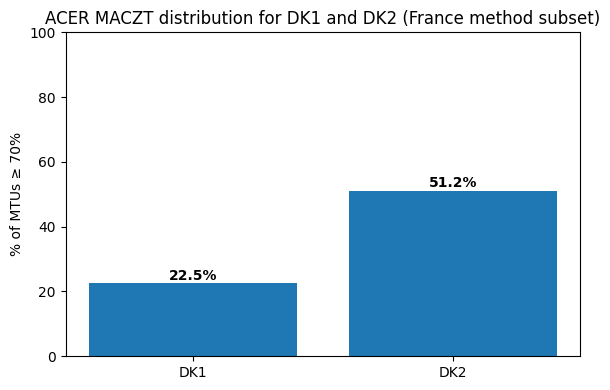

In [11]:

df_acer = acer_method.run_acer_method(df, zones=['DK1', 'DK2']) 

# Plot the compliance results over time for all selected zones
# This gives a visual plot like the entsoe market report
#ntsoe_market_plotting.plot_all_acer_zones(df_acer)

# Plot the percentage of hours where the compliance ratio is above 70%
# This helps evaluate whether the zones meet the regulatory 70% requirement
raw_compliance_plotting.plot_pct_above_70(df_acer, title_template="ACER MACZT distribution for DK1 and DK2 (France method subset)")





### 6. Influence on Viking Link in the first two months of 2026
Finally, we analyse the impact of the compliance results and constraints on **Viking Link** during **January and February 2026**.  
The objective is to understand whether the observed constraints materially influence the commercial possibilities on the interconnector.

In [12]:
# Filepath to the Viking Link Flow-Based dataset (CSV file)
# The file contains domain data for the period 1 Jan 2026 to 25 Feb 2026
filepath = r"C:\Users\JAEOL\OneDrive - Energinet.dk\Skrivebord\2026\FSTS\Market.Coupling.FSTS\2026_FB_domain_viking_link\ig118_ENDK_2026-01-01_to_2026-02-25.csv"

df_viking_link = pd.read_csv(filepath)


In [13]:

# Prepare the Viking Link dataframe
# This function renames columns, extracts bidding zones, merges forecasted flow,
# calculates the PTDF zone to zone
df_viking_link = viking_link_MNCC.prepare_viking_link_dataframe(df_viking_link)

In [14]:
# Compute the compliance ratio 
# MNCC is included to account for the Viking Link market impact
df_viking_link['ratio'] = (df_viking_link['ram']+df_viking_link['aac']+df_viking_link['MNCC'])/df_viking_link['fmax']  # this is need for all methods

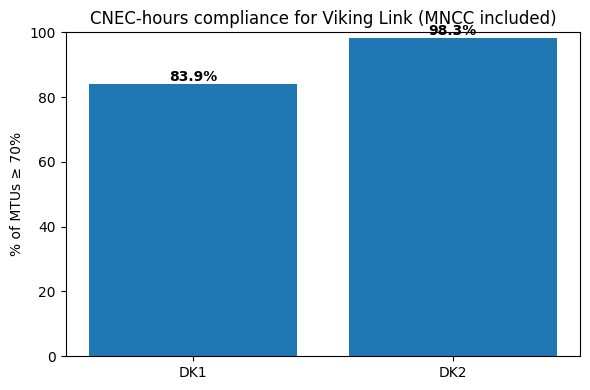

In [15]:
cnec_hours_df = cnec_hours_method.run_cnec_hours_method(df_viking_link)  # TODO: indsæt en titel tekst man kan sætte som input til funktionen. 
raw_compliance_plotting.plot_pct_above_70(cnec_hours_df, title_template="CNEC-hours compliance for Viking Link (MNCC included)")


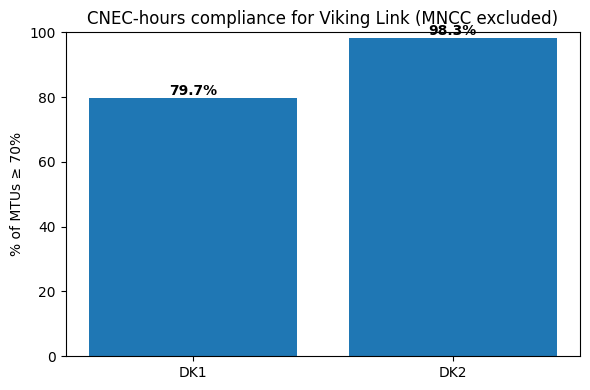

In [16]:
# when we for this period take the influence of MNCC out, we see that the compliance ratio is lower
df_viking_link['ratio'] = (df_viking_link['ram']+df_viking_link['aac'])/df_viking_link['fmax']  # this is need for all methods
cnec_hours_df = cnec_hours_method.run_cnec_hours_method(df_viking_link)
raw_compliance_plotting.plot_pct_above_70(cnec_hours_df, title_template="CNEC-hours compliance for Viking Link (MNCC excluded)")